# 01 - EDA\n
Análise exploratória inicial dos dados de crédito.

# Credit Default Prediction — Análise Exploratória de Dados (EDA)

**Objetivo:** Compreender o dataset de inadimplência de crédito antes de modelar.  
**Dataset:** Give Me Some Credit – Kaggle  
**Autor:** Cristian | PUC Minas EAD – IA e Machine Learning

In [3]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações gerais
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid', palette='muted')

import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [4]:
# Carregando o dataset
df = pd.read_csv('../data/cs-training.csv', index_col=0)

print(f"Shape: {df.shape}")
print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
df.head()

Shape: (150000, 11)
Linhas: 150,000 | Colunas: 11


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


## 1. Visão Geral do Dataset

In [5]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [6]:
# Estatísticas descritivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0000,0.0668,0.2497,0.0000,0.0000,0.0000,0.0000,1.0000
RevolvingUtilizationOfUnsecuredLines,150000.0000,6.0484,249.7554,0.0000,0.0299,0.1542,0.5590,50708.0000
age,150000.0000,52.2952,14.7719,0.0000,41.0000,52.0000,63.0000,109.0000
NumberOfTime30-59DaysPastDueNotWorse,150000.0000,0.4210,4.1928,0.0000,0.0000,0.0000,0.0000,98.0000
DebtRatio,150000.0000,353.0051,2037.8185,0.0000,0.1751,0.3665,0.8683,329664.0000
MonthlyIncome,120269.0000,6670.2212,14384.6742,0.0000,3400.0000,5400.0000,8249.0000,3008750.0000
NumberOfOpenCreditLinesAndLoans,150000.0000,8.4528,5.1460,0.0000,5.0000,8.0000,11.0000,58.0000
NumberOfTimes90DaysLate,150000.0000,0.2660,4.1693,0.0000,0.0000,0.0000,0.0000,98.0000
NumberRealEstateLoansOrLines,150000.0000,1.0182,1.1298,0.0000,0.0000,1.0000,2.0000,54.0000
NumberOfTime60-89DaysPastDueNotWorse,150000.0000,0.2404,4.1552,0.0000,0.0000,0.0000,0.0000,98.0000


## 2. Valores Nulos

                    Nulos  Percentual (%)
MonthlyIncome       29731         19.8200
NumberOfDependents   3924          2.6200


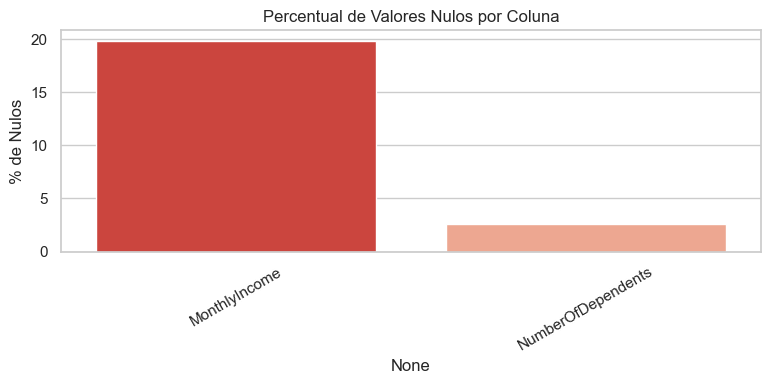

In [7]:
# Contagem e percentual de valores nulos
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Percentual (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos = nulos[nulos['Nulos'] > 0].sort_values('Percentual (%)', ascending=False)
print(nulos)

# Visualização
plt.figure(figsize=(8, 4))
sns.barplot(x=nulos.index, y=nulos['Percentual (%)'], palette='Reds_r')
plt.title('Percentual de Valores Nulos por Coluna')
plt.ylabel('% de Nulos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/figures/01_nulos.png', dpi=150)
plt.show()

## 3. Distribuição da Variável Alvo (Desbalanceamento)

Contagem:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Percentual:
SeriousDlqin2yrs
0   93.3200
1    6.6800
Name: proportion, dtype: float64


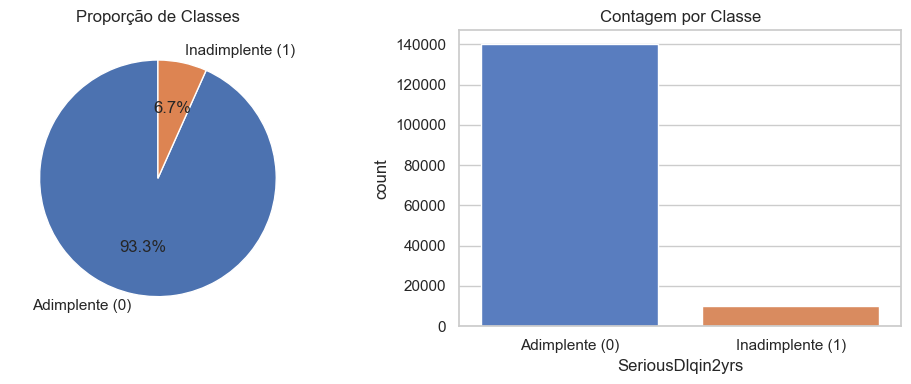

In [8]:
# Distribuição da variável alvo
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
print(target_pct.round(2))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].pie(target_counts, labels=['Adimplente (0)', 'Inadimplente (1)'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0].set_title('Proporção de Classes')

sns.countplot(x='SeriousDlqin2yrs', data=df, palette='muted', ax=axes[1])
axes[1].set_title('Contagem por Classe')
axes[1].set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'])

plt.tight_layout()
plt.savefig('../outputs/figures/02_desbalanceamento.png', dpi=150)
plt.show()

## 4. Distribuição das Variáveis Numéricas

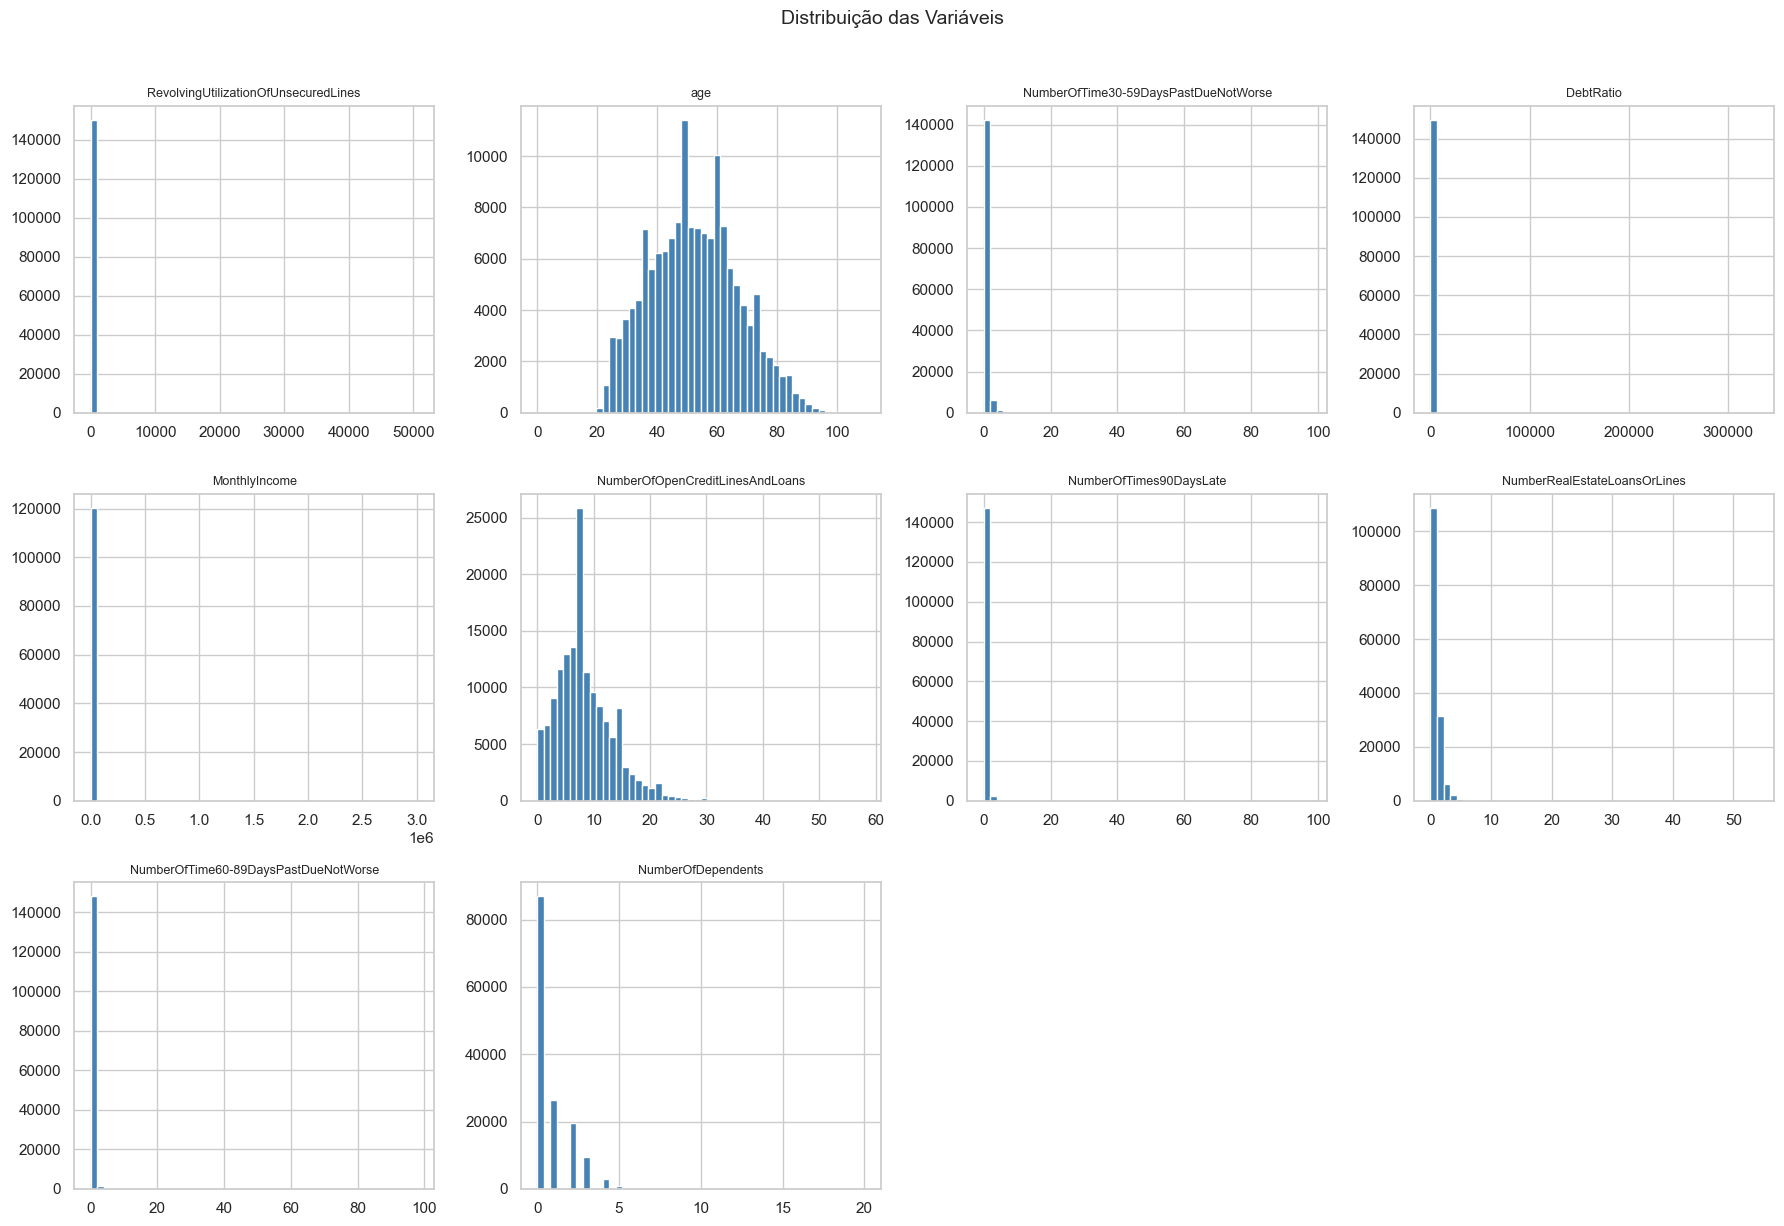

In [9]:
# Histogramas de todas as variáveis numéricas
features = df.drop(columns=['SeriousDlqin2yrs']).columns.tolist()

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

# Remover eixos extras se houver
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Variáveis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/03_distribuicoes.png', dpi=150)
plt.show()

## 5. Correlação entre Variáveis

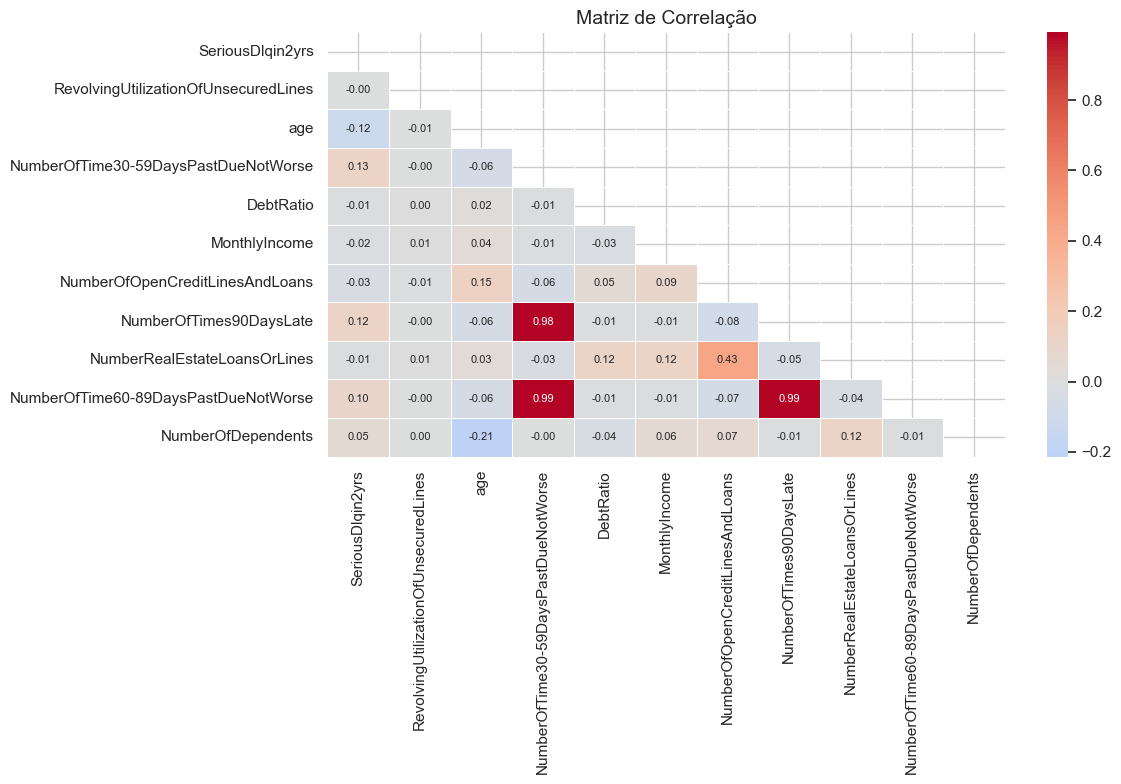

In [10]:
# Mapa de calor de correlações
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # apenas triângulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Matriz de Correlação', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/04_correlacao.png', dpi=150)
plt.show()

## 6. Análise Bivariada — Variáveis vs Alvo

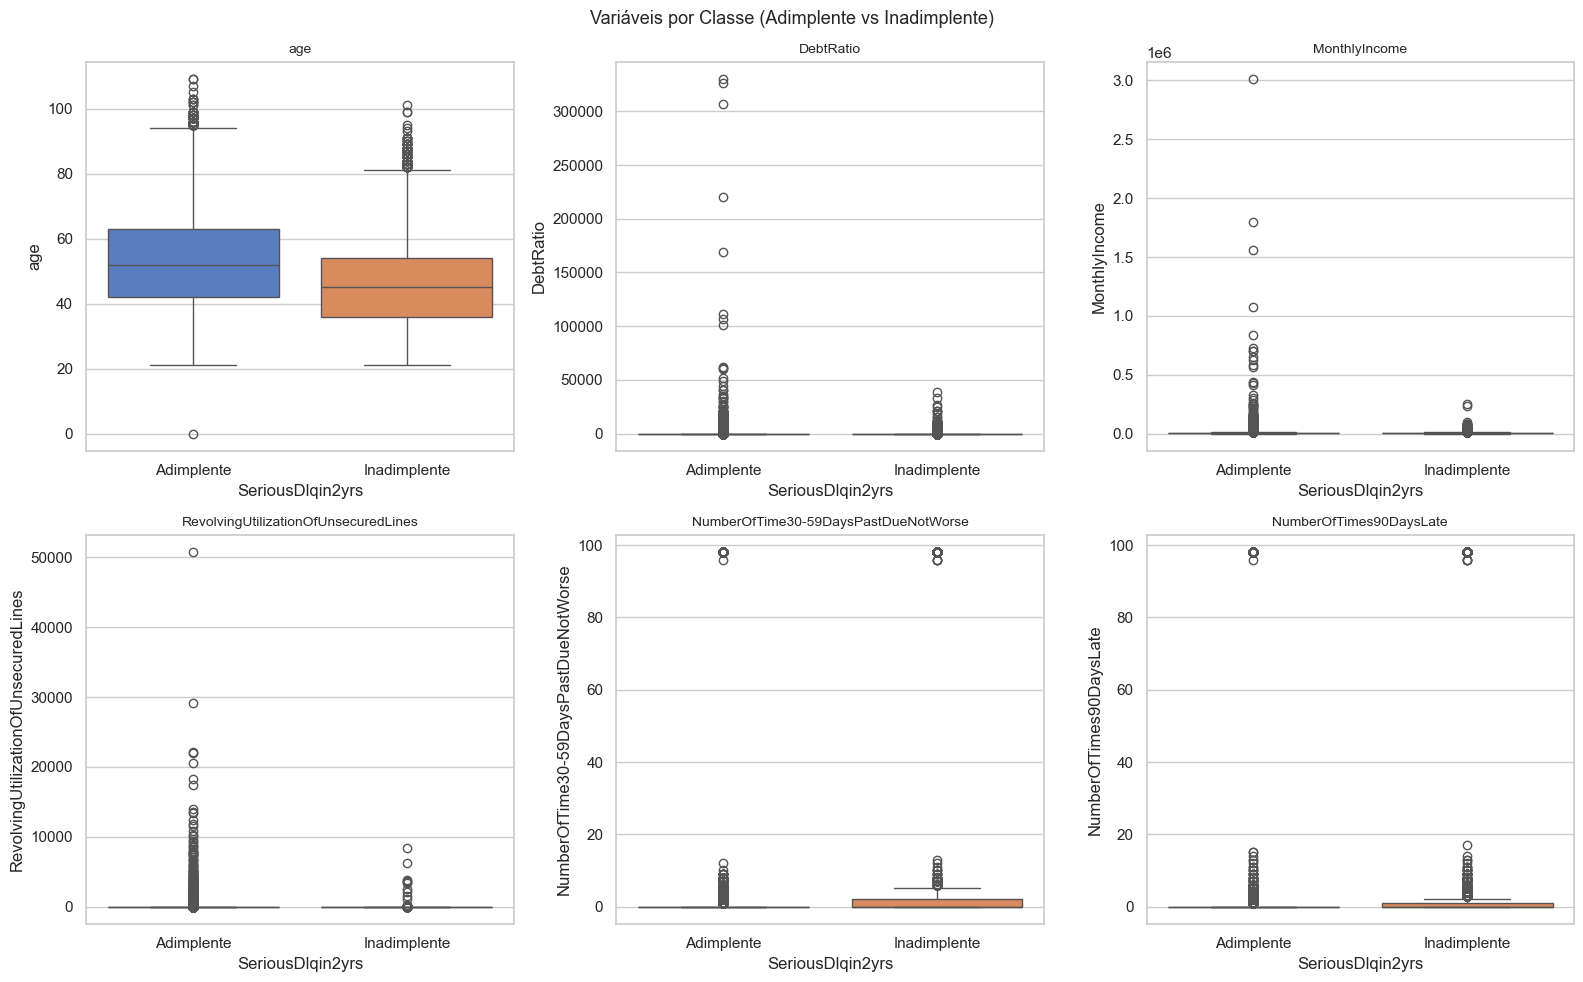

In [11]:
# Boxplots das principais variáveis por classe (alvo)
features_interesse = [
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features_interesse):
    sns.boxplot(
        x='SeriousDlqin2yrs',
        y=col,
        data=df,
        palette='muted',
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels(['Adimplente', 'Inadimplente'])

plt.suptitle('Variáveis por Classe (Adimplente vs Inadimplente)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/05_bivariada.png', dpi=150)
plt.show()

## 7. Principais Insights da EDA

- O dataset possui **150.000 registros e 11 variáveis numéricas**, todas do tipo inteiro ou contínuo, o que facilita a aplicação de modelos de Machine Learning supervisionados.
- A variável alvo `SeriousDlqin2yrs` é **fortemente desbalanceada**: a grande maioria dos clientes é adimplente, enquanto uma minoria (cerca de 6–7%) é inadimplente.  
  Isso significa que um modelo trivial que prevê sempre "não inadimplente" já teria alta acurácia, portanto **acurácia sozinha não é uma métrica adequada**. Na modelagem, será importante utilizar métricas como **ROC-AUC, Recall, Precision e F1-score**, além de considerar técnicas para tratar o desbalanceamento (por exemplo, `class_weight='balanced'` ou estratégias de oversampling/undersampling).
- As variáveis `MonthlyIncome` e `NumberOfDependents` apresentam **valores nulos**:
  - `MonthlyIncome` possui aproximadamente **19,82%** de valores ausentes, o que indica que cerca de 1 em cada 5 clientes não tem renda registrada. Por ser uma variável relevante de negócio, ela será mantida e seus nulos serão **imputados**, por exemplo, pela **mediana**, podendo ainda ser criada uma variável indicadora para sinalizar casos em que a renda foi imputada.
  - `NumberOfDependents` possui cerca de **2,62%** de valores ausentes. Como o percentual é relativamente baixo, essa variável também será mantida, com imputação (por exemplo, por 0 ou pela mediana, conforme a distribuição observada).
- A análise descritiva e os gráficos de distribuição indicam a presença de **valores extremos (outliers)** em algumas variáveis, como:
  - `age`, com valores mínimos suspeitos (ex.: idade 0), que não fazem sentido em termos de negócio e provavelmente representam erros de registro;
  - variáveis relacionadas ao uso de crédito e dívidas, como `DebtRatio` e `RevolvingUtilizationOfUnsecuredLines`, que apresentam valores muito altos para uma minoria dos clientes;
  - variáveis de atraso (`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`), com contagens de atrasos muito elevadas em poucos casos.
  Esses outliers e valores inválidos precisarão de **tratamento específico** (remoção ou truncamento) antes da modelagem.
- A análise bivariada (boxplots e correlações) mostra que variáveis relacionadas a **atrasos de pagamento** (`NumberOfTimes90DaysLate`, `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`) apresentam valores significativamente maiores para a classe de clientes inadimplentes (alvo = 1) em comparação com a classe adimplente.  
  Isso sugere que essas variáveis têm **forte potencial preditivo** para o risco de inadimplência e devem ser tratadas com atenção na etapa de modelagem.
- Outras variáveis financeiras, como `DebtRatio`, `MonthlyIncome` e `NumberOfOpenCreditLinesAndLoans`, também mostram comportamentos diferentes entre clientes adimplentes e inadimplentes, indicando que a **combinação dessas informações** pode ser útil para o modelo aprender padrões de risco.

## Próximos passos

- **Tratamento de nulos**: imputar `MonthlyIncome` (por exemplo, com a mediana) e `NumberOfDependents` (com 0 ou mediana, conforme a distribuição), e opcionalmente criar variáveis indicadoras para sinalizar imputações.
- **Tratamento de valores inválidos e outliers**: remover registros claramente inconsistentes (como `age <= 0`) e avaliar estratégias para limitar/truncar valores extremos em variáveis como `DebtRatio` e contagens de atrasos.
- **Feature engineering**: criar novas variáveis derivadas, como o total de atrasos combinando as diferentes janelas de atraso, ou razões entre dívida e renda, para enriquecer o espaço de features.
- **Preparação para modelagem**: separar as variáveis explicativas (`X`) e a variável alvo (`y`), realizar o split em treino e teste, e então avançar para o notebook `02_modeling.ipynb`, onde serão testados modelos de classificação (por exemplo, Regressão Logística, Random Forest, Gradient Boosting/XGBoost) com métricas adequadas ao cenário desbalanceado.